In [69]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [70]:
df = pd.read_csv("../data/preprocessed_train.csv")

target_col = "TARGET"
id_col = "SK_ID_CURR"

X = df.drop(columns=[target_col])
y = df[target_col]

if id_col in X.columns:
    X = X.drop(columns=[id_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = joblib.load("../models/best_model.pkl")

print(X_train.shape, X_test.shape)
print(type(model))

(246008, 242) (61503, 242)
<class 'xgboost.sklearn.XGBClassifier'>


In [71]:
y_proba = model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
test_gini = 2 * test_auc - 1

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
test_ks = np.max(tpr - fpr)

print("Test AUROC:", test_auc)
print("Test Gini:", test_gini)
print("Test KS:", test_ks)

Test AUROC: 0.7696600976013886
Test Gini: 0.5393201952027773
Test KS: 0.40243138881862095


In [72]:
os.makedirs("../models", exist_ok=True)

# Sample for global SHAP plots
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Handle SHAP returning a list for binary models in some versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

def get_base_value(explainer):
    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)):
        ev = np.atleast_1d(ev)
        return float(ev[1]) if len(ev) > 1 else float(ev[0])
    return float(ev)

base_value = get_base_value(explainer)

np.save("../models/shap_values.npy", shap_values)
X_shap.to_csv("../models/shap_sample.csv", index=False)

print(shap_values.shape)

(1000, 242)


c:\Users\humza\Documents\VSCODE_Projects\jarvis_data_eng_HumzaInam\credit_risk_scoring_ml\venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\humza\AppData\Local\Temp\ipykernel_21800\254798169.py:3: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


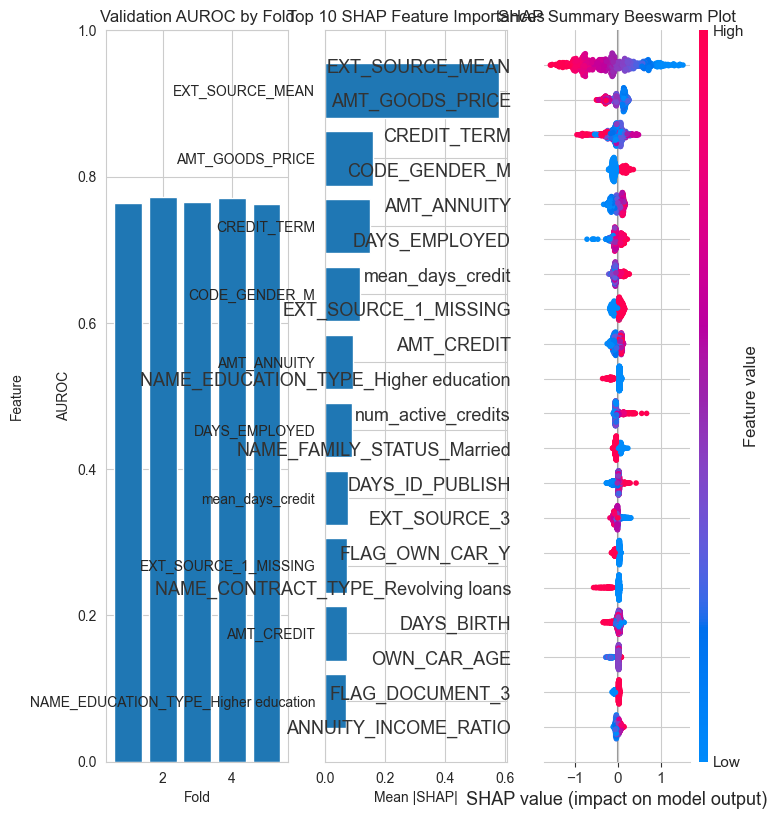

In [73]:
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Beeswarm Plot")
plt.tight_layout()
plt.show()

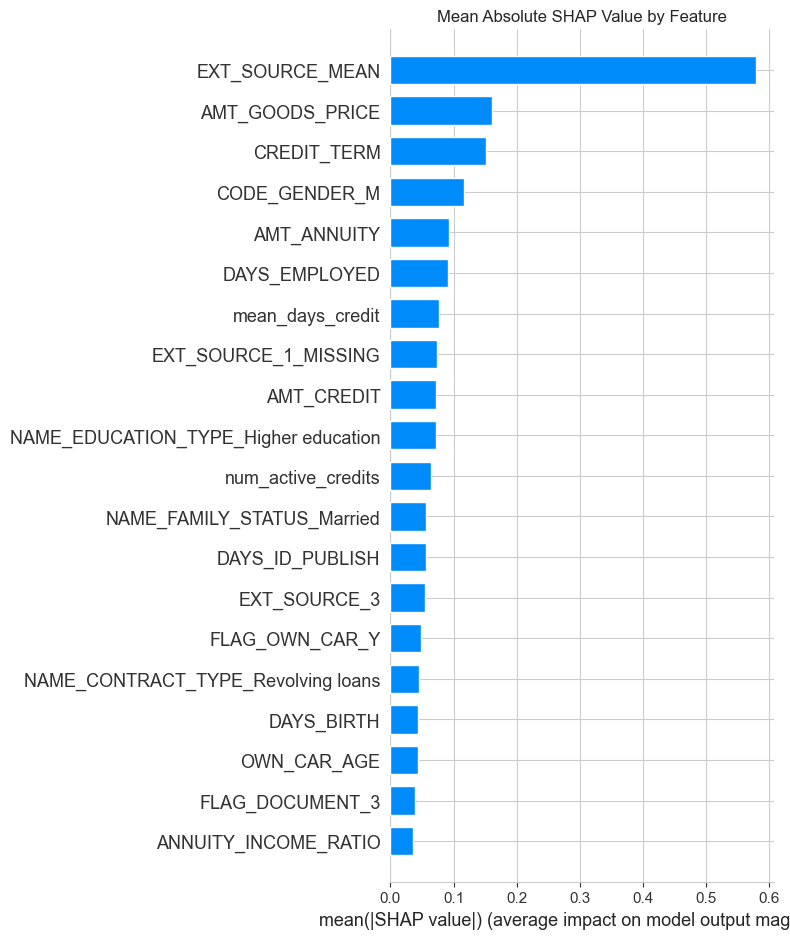

In [74]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Value by Feature")
plt.tight_layout()
plt.show()

In [75]:
risk_scores = pd.Series(y_proba, index=X_test.index)

def pick_index_by_range(scores, low, high=None, fallback_target=None):
    if high is None:
        subset = scores[scores >= low]
    else:
        subset = scores[(scores >= low) & (scores <= high)]
    if len(subset) > 0:
        return subset.index[0]
    if fallback_target is None:
        fallback_target = low if high is None else (low + high) / 2
    return (scores - fallback_target).abs().idxmin()

high_idx = pick_index_by_range(risk_scores, 0.5, None, 0.65)
borderline_idx = pick_index_by_range(risk_scores, 0.2, 0.4, 0.30)
low_idx = pick_index_by_range(risk_scores, 0.0, 0.1, 0.05)

selected = {
    "high-risk": high_idx,
    "borderline": borderline_idx,
    "low-risk": low_idx,
}

selected

{'high-risk': np.int64(103497),
 'borderline': np.int64(130646),
 'low-risk': np.int64(287975)}

In [76]:
friendly_names = {
    "EXT_SOURCE_1": "External credit score 1",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_3": "External credit score 3",
    "CREDIT_INCOME_RATIO": "Credit-to-income ratio",
    "ANNUITY_INCOME_RATIO": "Annuity-to-income ratio",
    "CREDIT_TERM": "Credit term",
    "DAYS_EMPLOYED_RATIO": "Employment stability ratio",
    "INCOME_PER_PERSON": "Income per family member",
    "num_bureau_records": "Number of bureau records",
    "num_active_credits": "Number of active credits",
    "mean_days_credit": "Mean days since credit",
    "max_overdue": "Maximum overdue amount",
    "age": "Applicant age",
}

In [77]:
def explain_one_applicant(idx, label):
    x_row = X_test.loc[[idx]]
    row_pred = model.predict_proba(x_row)[:, 1][0]

    row_shap = explainer.shap_values(x_row)
    if isinstance(row_shap, list):
        row_shap = row_shap[1]
    row_shap = np.array(row_shap).reshape(-1)

    print(f"\n{label.upper()} APPLICANT")
    print("Index:", idx)
    print("Predicted probability of default:", round(float(row_pred), 4))

    explanation = shap.Explanation(
        values=row_shap,
        base_values=base_value,
        data=x_row.iloc[0].values,
        feature_names=x_row.columns.tolist()
    )

    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"SHAP Waterfall - {label.title()} Applicant")
    plt.tight_layout()
    plt.show()

    contrib = pd.Series(row_shap, index=x_row.columns)

    positive = contrib[contrib > 0].sort_values(ascending=False)
    if positive.empty:
        positive = contrib.abs().sort_values(ascending=False)

    top_reasons = positive.head(4)

    print("\nTop reasons:")
    for feat, val in top_reasons.items():
        display_name = friendly_names.get(feat, feat)
        print(f"- {display_name}: contribution {val:.4f}")

    return row_pred, row_shap


HIGH-RISK APPLICANT
Index: 103497
Predicted probability of default: 0.7646


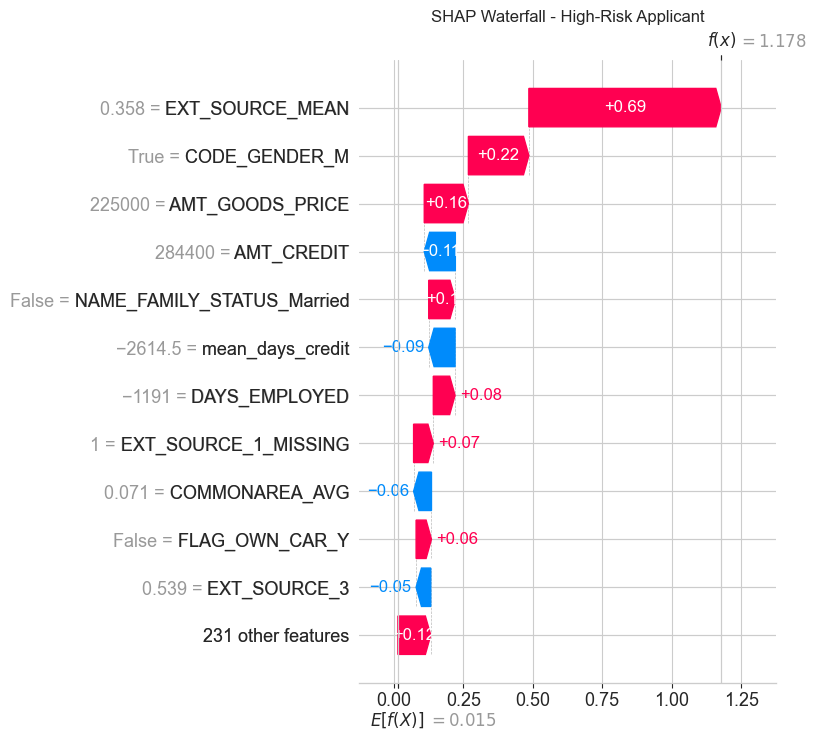


Top reasons:
- EXT_SOURCE_MEAN: contribution 0.6920
- CODE_GENDER_M: contribution 0.2176
- AMT_GOODS_PRICE: contribution 0.1588
- NAME_FAMILY_STATUS_Married: contribution 0.0958

BORDERLINE APPLICANT
Index: 130646
Predicted probability of default: 0.3322


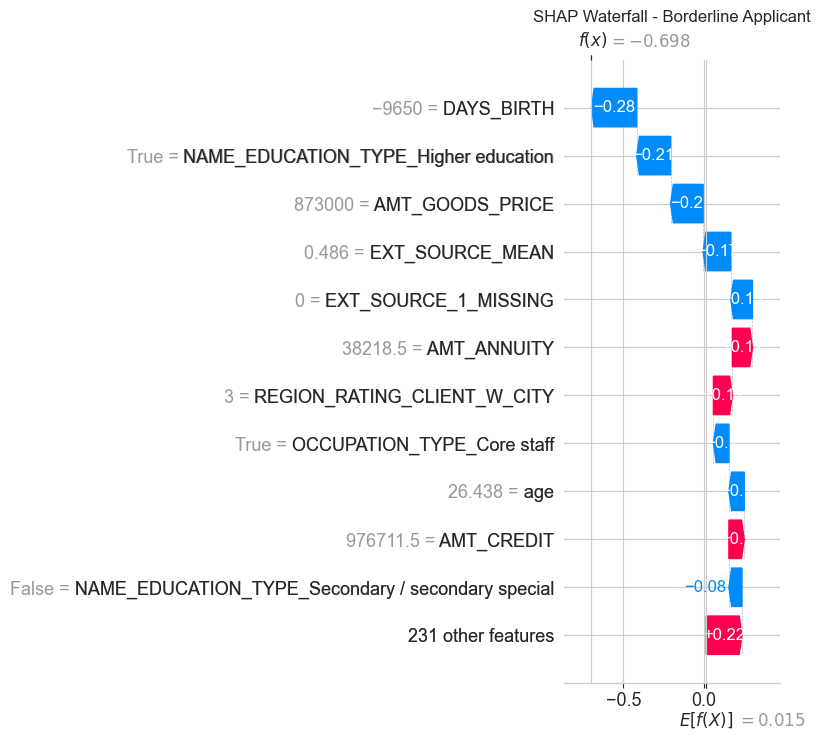


Top reasons:
- AMT_ANNUITY: contribution 0.1248
- REGION_RATING_CLIENT_W_CITY: contribution 0.1175
- AMT_CREDIT: contribution 0.0952
- DAYS_EMPLOYED: contribution 0.0758

LOW-RISK APPLICANT
Index: 287975
Predicted probability of default: 0.0971


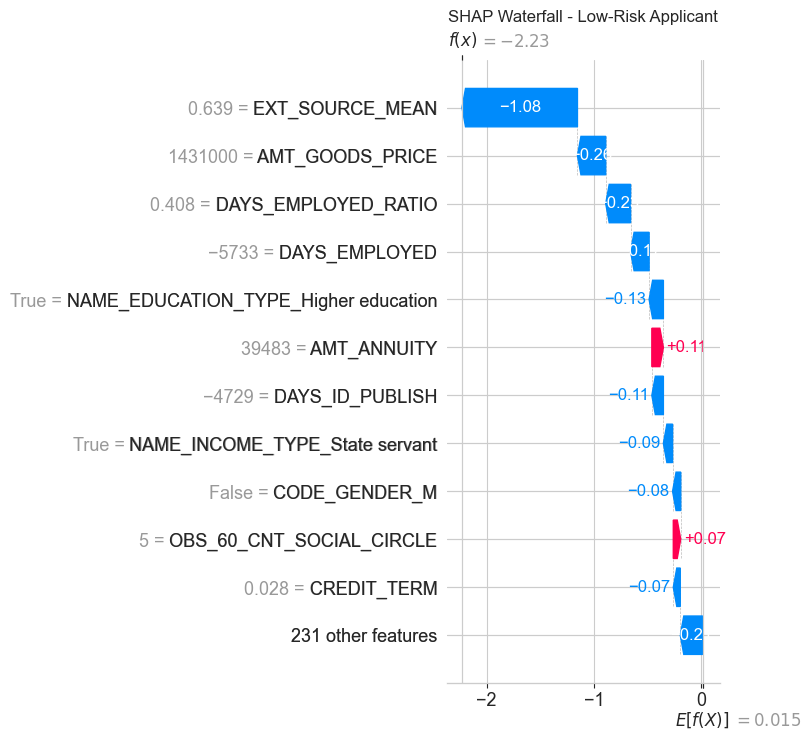


Top reasons:
- AMT_ANNUITY: contribution 0.1077
- OBS_60_CNT_SOCIAL_CIRCLE: contribution 0.0694
- REGION_RATING_CLIENT_W_CITY: contribution 0.0573
- EXT_SOURCE_1_MISSING: contribution 0.0507


In [78]:
high_pred, high_shap = explain_one_applicant(selected["high-risk"], "high-risk")
border_pred, border_shap = explain_one_applicant(selected["borderline"], "borderline")
low_pred, low_shap = explain_one_applicant(selected["low-risk"], "low-risk")

In [79]:
x_high = X_test.loc[[selected["high-risk"]]]
row_shap = explainer.shap_values(x_high)
if isinstance(row_shap, list):
    row_shap = row_shap[1]
row_shap = np.array(row_shap).reshape(-1)

contrib = pd.Series(row_shap, index=x_high.columns)
positive = contrib[contrib > 0].sort_values(ascending=False)
if positive.empty:
    positive = contrib.abs().sort_values(ascending=False)

top_4 = positive.head(4)

print("ADVERSE ACTION NOTICE")
print("-----------------------------------")
print("Your application was declined because the model identified a higher probability of default.")
print("Main factors contributing to this decision:")
for feat, val in top_4.items():
    display_name = friendly_names.get(feat, feat)
    print(f"- {display_name} ({val:.4f})")

ADVERSE ACTION NOTICE
-----------------------------------
Your application was declined because the model identified a higher probability of default.
Main factors contributing to this decision:
- EXT_SOURCE_MEAN (0.6920)
- CODE_GENDER_M (0.2176)
- AMT_GOODS_PRICE (0.1588)
- NAME_FAMILY_STATUS_Married (0.0958)


In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("Fold AUROCs:", cv_scores)
print("Mean AUROC:", cv_scores.mean())
print("Std AUROC:", cv_scores.std())

Fold AUROCs: [0.76344839 0.77168675 0.76468499 0.77107273 0.76289204]
Mean AUROC: 0.7667569799383174
Std AUROC: 0.0038237677011922415


In [81]:
def calculate_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() < 2 or actual.nunique() < 2:
        return np.nan

    # Use quantile bins from expected distribution
    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))

    if len(breakpoints) < 3:
        return np.nan

    eps = 1e-6

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates="drop")
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates="drop")

    expected_dist = expected_bins.value_counts(normalize=True, sort=False)
    actual_dist = actual_bins.value_counts(normalize=True, sort=False)

    expected_dist, actual_dist = expected_dist.align(actual_dist, fill_value=0)

    expected_dist = expected_dist + eps
    actual_dist = actual_dist + eps

    psi = ((actual_dist - expected_dist) * np.log(actual_dist / expected_dist)).sum()
    return float(psi)

In [82]:
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": shap_importance
}).sort_values("mean_abs_shap", ascending=False)

top_10_features = importance_df["feature"].head(10).tolist()
top_10_features

['EXT_SOURCE_MEAN',
 'AMT_GOODS_PRICE',
 'CREDIT_TERM',
 'CODE_GENDER_M',
 'AMT_ANNUITY',
 'DAYS_EMPLOYED',
 'mean_days_credit',
 'EXT_SOURCE_1_MISSING',
 'AMT_CREDIT',
 'NAME_EDUCATION_TYPE_Higher education']

In [83]:
numeric_top10 = [feat for feat in top_10_features if np.issubdtype(X_train[feat].dtype, np.number)]
print("Numeric features for PSI:", numeric_top10)

Numeric features for PSI: ['EXT_SOURCE_MEAN', 'AMT_GOODS_PRICE', 'CREDIT_TERM', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'mean_days_credit', 'EXT_SOURCE_1_MISSING', 'AMT_CREDIT']


In [84]:
psi_results = []

for feat in numeric_top10:
    psi_val = calculate_psi(X_train[feat], X_test[feat], buckets=10)
    psi_results.append({"feature": feat, "psi": psi_val})

psi_df = pd.DataFrame(psi_results).sort_values("psi", ascending=False)
psi_df

,feature,psi
3,AMT_ANNUITY,0.000247
4,DAYS_EMPLOYED,0.000242
0,EXT_SOURCE_MEAN,0.000217
2,CREDIT_TERM,0.000215
1,AMT_GOODS_PRICE,0.000123
5,mean_days_credit,0.000118
7,AMT_CREDIT,0.000109
6,EXT_SOURCE_1_MISSING,NaN


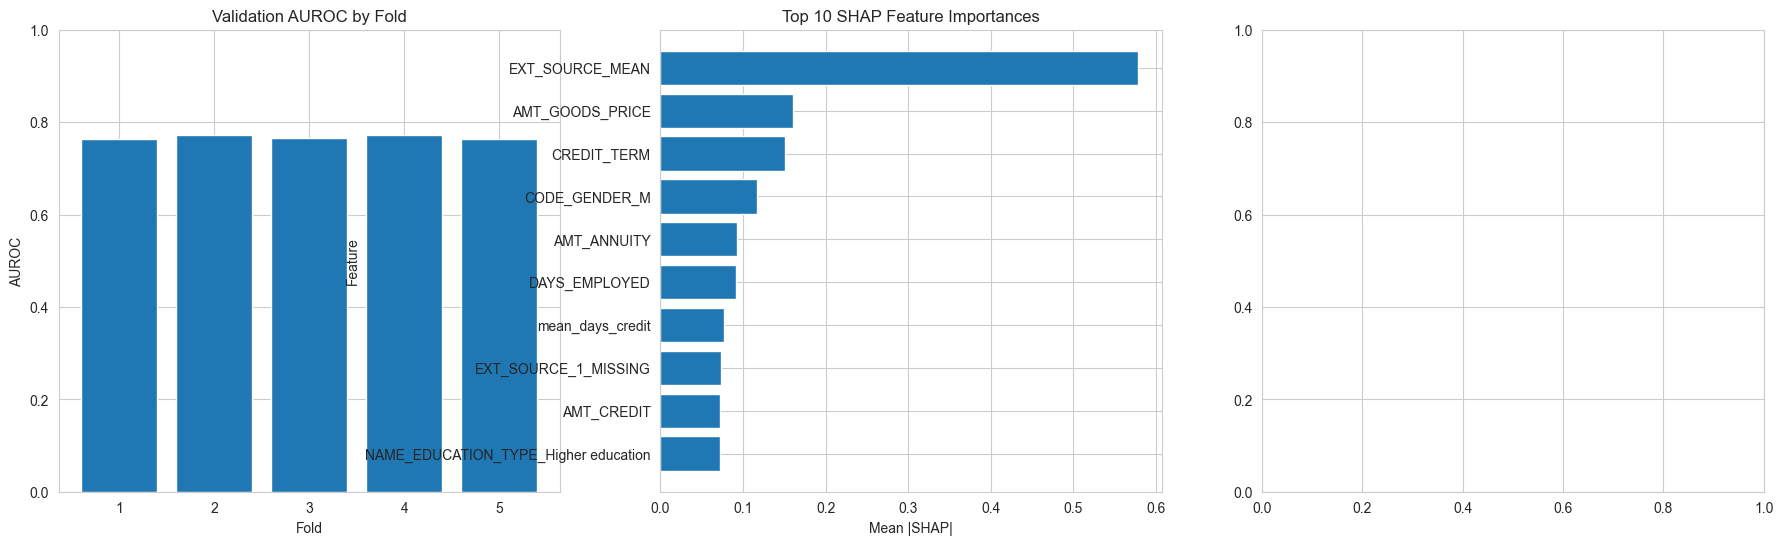

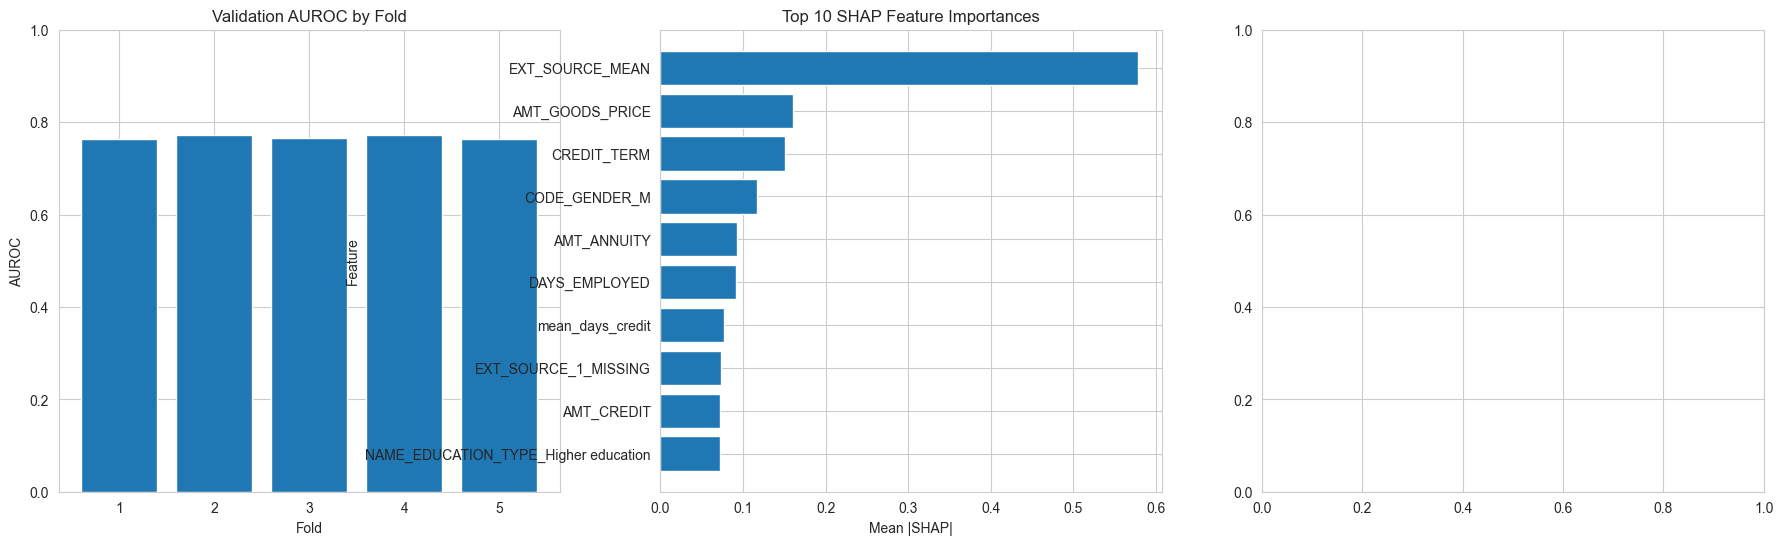

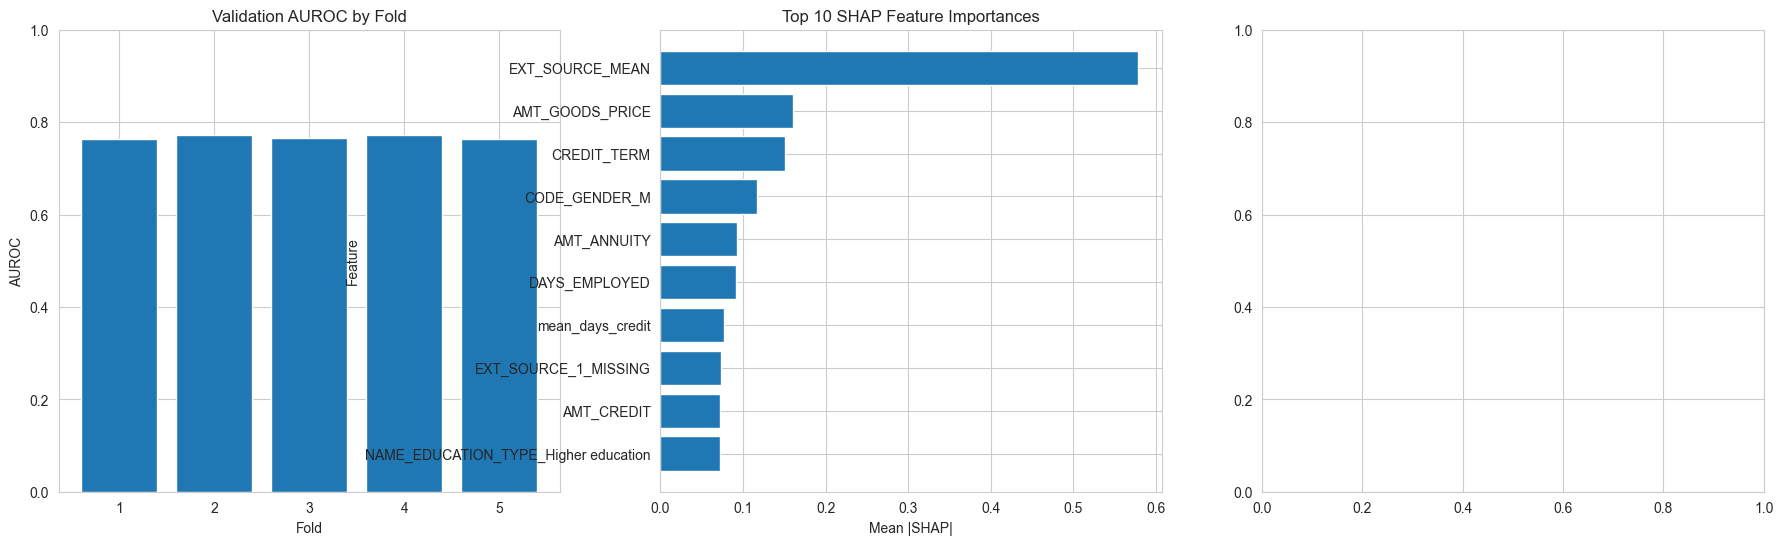

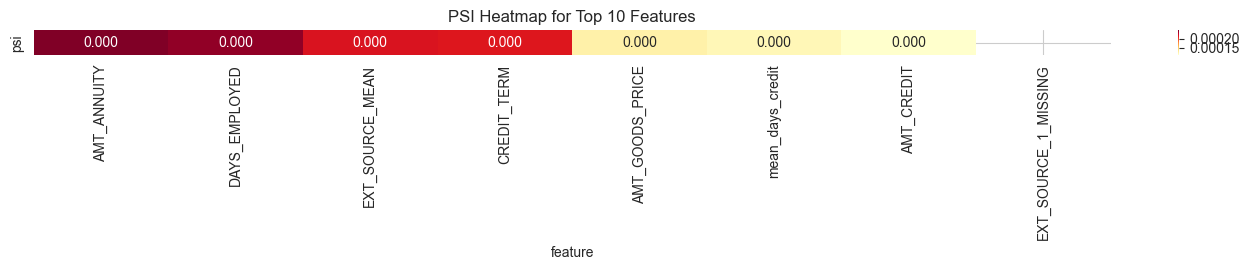

In [88]:
psi_heat = psi_df.set_index("feature").T

plt.figure(figsize=(14, 2.8))
sns.heatmap(psi_heat, annot=True, fmt=".3f", cmap="YlOrRd", cbar=True)
plt.title("PSI Heatmap for Top 10 Features")
plt.tight_layout()
plt.show()

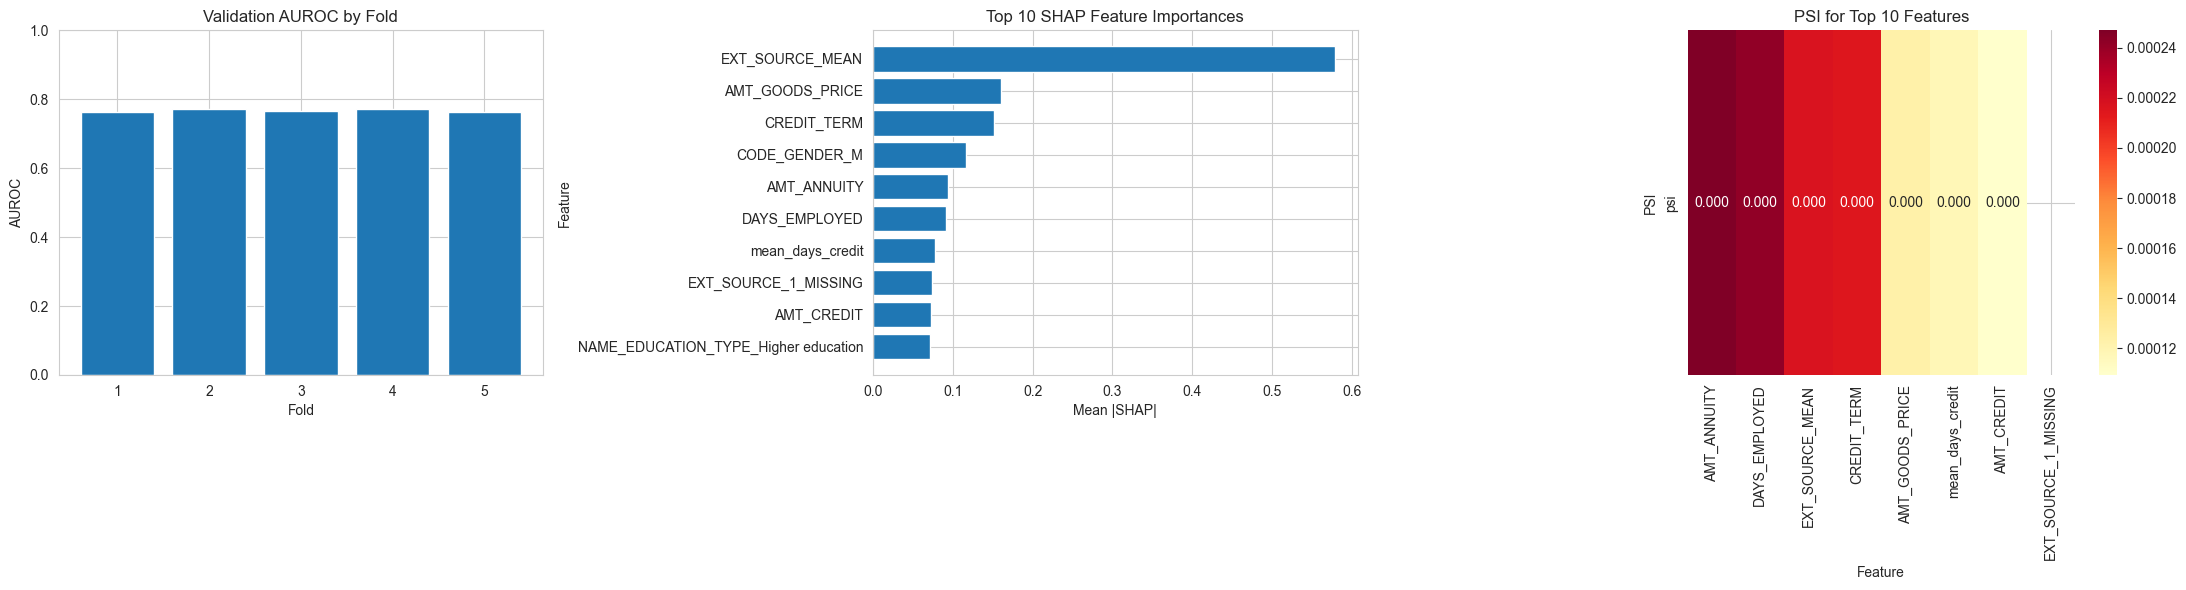

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# A) CV AUROC by fold
axes[0].bar(range(1, len(cv_scores) + 1), cv_scores)
axes[0].set_title("Validation AUROC by Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("AUROC")
axes[0].set_ylim(0, 1)

# B) Top 10 feature importances
top10_imp = importance_df.head(10).sort_values("mean_abs_shap")
axes[1].barh(top10_imp["feature"], top10_imp["mean_abs_shap"])
axes[1].set_title("Top 10 SHAP Feature Importances")
axes[1].set_xlabel("Mean |SHAP|")
axes[1].set_ylabel("Feature")

# C) PSI heatmap
sns.heatmap(psi_heat, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[2], cbar=True)
axes[2].set_title("PSI for Top 10 Features")
axes[2].set_xlabel("Feature")
axes[2].set_ylabel("PSI")

plt.tight_layout()
plt.show()

In [90]:
psi_df.to_csv("../reports/psi_report.csv", index=False)
importance_df.to_csv("../reports/shap_importance.csv", index=False)

print("Saved SHAP and PSI outputs.")

Saved SHAP and PSI outputs.
